# Interpretability-Flavored JEPA on CIFAR-10

A small I-JEPA (Image Joint-Embedding Predictive Architecture) implementation,
trained on CIFAR-10, followed by a mechanistic analysis of what the learned
representations look like: collapse/effective-rank checks, per-layer attention
entropy, linear probing by depth, and a Sparse Autoencoder trained on the
target-encoder representations.

**Runtime:** GPU (T4 is fine). Expect ~30-50 min for training + analysis at
this model size.

Run all cells top to bottom. Everything (model code, training, analysis,
plots) is self-contained in this notebook.

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

CUDA available: True
device: cuda


## 1. Model code

Writes out the JEPA model (`model/jepa.py`) so it can be imported normally.

In [2]:
import os
os.makedirs('model', exist_ok=True)
os.makedirs('analysis', exist_ok=True)
open('model/__init__.py', 'w').close()
open('analysis/__init__.py', 'w').close()

In [3]:
%%writefile model/jepa.py
"""
Minimal I-JEPA implementation.

Core idea (Assran et al., 2023): instead of reconstructing masked pixels
(MAE) or contrastive instance discrimination (SimCLR), JEPA predicts the
*representation* of masked target patches from the representation of
visible context patches, using a separate predictor network. The target
encoder is an EMA (exponential moving average) copy of the context
encoder, and gradients never flow into it (stop-gradient) -- this, plus
the asymmetric predictor, is what prevents representation collapse
(everything mapping to a constant vector), which is the central failure
mode this whole architecture is designed around.

Components:
  - PatchEmbed: image -> patch tokens
  - ViTEncoder: standard pre-norm transformer encoder (used for both
    context and target encoders; target is an EMA copy, never trained
    by gradient descent)
  - Predictor: small transformer that takes context tokens + mask tokens
    (with positional embeddings for the masked positions) and predicts
    target-encoder representations at those positions
  - JEPA: wraps the above, implements masking + EMA update + loss
"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def build_2d_sincos_pos_embed(embed_dim, grid_size):
    """Fixed sin-cos positional embeddings, standard ViT/MAE recipe."""
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_w, grid_h, indexing="ij")
    grid = torch.stack(grid, dim=0).reshape(2, 1, grid_size, grid_size)

    assert embed_dim % 4 == 0
    dim_half = embed_dim // 2

    def sincos_1d(pos, dim):
        omega = torch.arange(dim // 2, dtype=torch.float32)
        omega = 1.0 / (10000 ** (omega / (dim // 2)))
        pos = pos.reshape(-1)
        out = pos[:, None] * omega[None, :]
        return torch.cat([torch.sin(out), torch.cos(out)], dim=1)

    emb_h = sincos_1d(grid[0], dim_half)
    emb_w = sincos_1d(grid[1], dim_half)
    return torch.cat([emb_h, emb_w], dim=1)  # (grid_size**2, embed_dim)


class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128):
        super().__init__()
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)               # (B, C, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, N, C)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim)
        )

    def forward(self, x, return_attn=False):
        h = self.norm1(x)
        attn_out, attn_weights = self.attn(h, h, h, need_weights=return_attn, average_attn_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        if return_attn:
            return x, attn_weights
        return x


class ViTEncoder(nn.Module):
    """Used for both context encoder (trained) and target encoder (EMA copy)."""

    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128,
                 depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        grid_size = self.patch_embed.grid_size

        pos_embed = build_2d_sincos_pos_embed(embed_dim, grid_size)
        self.register_buffer("pos_embed", pos_embed.unsqueeze(0))  # (1, N, D)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim
        self.num_patches = num_patches

    def forward(self, x, patch_indices=None, return_all_layers=False, return_attn=False):
        """
        x: (B, C, H, W) images
        patch_indices: optional (B, K) indices of patches to keep (context encoder
            only sees these -- this is what makes it a *context* encoder)
        return_all_layers: if True, also return list of per-block outputs (for
            interpretability probing across depth)
        """
        tokens = self.patch_embed(x)  # (B, N, D)
        tokens = tokens + self.pos_embed

        if patch_indices is not None:
            B, K = patch_indices.shape
            idx = patch_indices.unsqueeze(-1).expand(-1, -1, tokens.shape[-1])
            tokens = torch.gather(tokens, 1, idx)  # (B, K, D)

        all_layers = []
        all_attn = []
        for blk in self.blocks:
            if return_attn:
                tokens, attn = blk(tokens, return_attn=True)
                all_attn.append(attn)
            else:
                tokens = blk(tokens)
            if return_all_layers:
                all_layers.append(tokens)

        tokens = self.norm(tokens)

        out = {"tokens": tokens}
        if return_all_layers:
            out["all_layers"] = all_layers
        if return_attn:
            out["all_attn"] = all_attn
        return out


class Predictor(nn.Module):
    """Narrow transformer: context tokens + mask tokens -> predicted target reps."""

    def __init__(self, embed_dim=128, predictor_dim=64, depth=3, num_heads=4, grid_size=8):
        super().__init__()
        self.embed_in = nn.Linear(embed_dim, predictor_dim)
        self.embed_out = nn.Linear(predictor_dim, embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)

        pos_embed = build_2d_sincos_pos_embed(predictor_dim, grid_size)
        self.register_buffer("pos_embed", pos_embed.unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(predictor_dim, num_heads, mlp_ratio=4.0) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(predictor_dim)

    def forward(self, context_tokens, context_indices, target_indices):
        """
        context_tokens: (B, K_ctx, D) output of context encoder
        context_indices: (B, K_ctx) which patch positions these are
        target_indices: (B, K_tgt) which patch positions to predict
        """
        B = context_tokens.shape[0]
        D = self.mask_token.shape[-1]

        ctx = self.embed_in(context_tokens)
        ctx_pos = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            context_indices.unsqueeze(-1).expand(-1, -1, self.pos_embed.shape[-1])
        )
        ctx = ctx + ctx_pos

        K_tgt = target_indices.shape[1]
        mask_tokens = self.mask_token.expand(B, K_tgt, -1)
        tgt_pos = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            target_indices.unsqueeze(-1).expand(-1, -1, self.pos_embed.shape[-1])
        )
        mask_tokens = mask_tokens + tgt_pos

        x = torch.cat([ctx, mask_tokens], dim=1)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        pred = x[:, ctx.shape[1]:]  # only the (formerly) mask-token positions
        return self.embed_out(pred)  # (B, K_tgt, embed_dim)


def block_mask(num_patches, grid_size, batch_size, device,
                num_target_blocks=4, target_scale=(0.15, 0.2),
                context_scale=(0.85, 1.0)):
    """
    I-JEPA style block masking: sample a handful of rectangular target
    blocks (what the predictor must guess) and a large context region
    (what the context encoder is allowed to see), with target regions
    removed from the context so the task can't be solved by copying.
    Returns index tensors, NOT boolean masks, since we gather() patches.
    """
    def sample_block_indices(scale_range):
        area = grid_size * grid_size
        target_area = area * (scale_range[0] + torch.rand(1).item() * (scale_range[1] - scale_range[0]))
        aspect = 0.75 + torch.rand(1).item() * 0.5
        h = max(1, min(grid_size, round(math.sqrt(target_area * aspect))))
        w = max(1, min(grid_size, round(math.sqrt(target_area / aspect))))
        top = torch.randint(0, grid_size - h + 1, (1,)).item()
        left = torch.randint(0, grid_size - w + 1, (1,)).item()
        idx = []
        for i in range(top, top + h):
            for j in range(left, left + w):
                idx.append(i * grid_size + j)
        return set(idx)

    all_context_idx, all_target_idx = [], []
    for _ in range(batch_size):
        target_set = set()
        for _ in range(num_target_blocks):
            target_set |= sample_block_indices(target_scale)
        context_set = sample_block_indices(context_scale)
        context_set = context_set - target_set  # no leakage

        if len(context_set) == 0:
            context_set = set(range(num_patches)) - target_set
        if len(target_set) == 0:
            target_set = {torch.randint(0, num_patches, (1,)).item()}

        all_context_idx.append(sorted(context_set))
        all_target_idx.append(sorted(target_set))

    min_ctx = min(len(x) for x in all_context_idx)
    min_tgt = min(len(x) for x in all_target_idx)
    all_context_idx = [x[:min_ctx] for x in all_context_idx]
    all_target_idx = [x[:min_tgt] for x in all_target_idx]

    context_indices = torch.tensor(all_context_idx, device=device, dtype=torch.long)
    target_indices = torch.tensor(all_target_idx, device=device, dtype=torch.long)
    return context_indices, target_indices


class JEPA(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128,
                 enc_depth=6, enc_heads=4, pred_dim=64, pred_depth=3, pred_heads=4,
                 ema_momentum=0.996):
        super().__init__()
        grid_size = img_size // patch_size
        self.context_encoder = ViTEncoder(img_size, patch_size, in_chans, embed_dim, enc_depth, enc_heads)
        self.target_encoder = ViTEncoder(img_size, patch_size, in_chans, embed_dim, enc_depth, enc_heads)
        self.predictor = Predictor(embed_dim, pred_dim, pred_depth, pred_heads, grid_size)

        # target encoder starts identical to context encoder, then is EMA-only
        self.target_encoder.load_state_dict(self.context_encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad = False

        self.ema_momentum = ema_momentum
        self.num_patches = self.context_encoder.num_patches

    @torch.no_grad()
    def update_target_encoder(self):
        m = self.ema_momentum
        for p_ctx, p_tgt in zip(self.context_encoder.parameters(), self.target_encoder.parameters()):
            p_tgt.data.mul_(m).add_(p_ctx.data, alpha=1 - m)

    def forward(self, images):
        B = images.shape[0]
        device = images.device
        grid_size = self.context_encoder.patch_embed.grid_size

        context_indices, target_indices = block_mask(
            self.num_patches, grid_size, B, device
        )

        ctx_out = self.context_encoder(images, patch_indices=context_indices)
        pred = self.predictor(ctx_out["tokens"], context_indices, target_indices)

        with torch.no_grad():
            tgt_out = self.target_encoder(images)  # full image, no masking
            target_full = tgt_out["tokens"]
            idx = target_indices.unsqueeze(-1).expand(-1, -1, target_full.shape[-1])
            target = torch.gather(target_full, 1, idx)
            target = F.layer_norm(target, (target.shape[-1],))  # stabilizes scale, standard trick

        loss = F.smooth_l1_loss(pred, target)
        return loss, {"pred": pred, "target": target}


Writing model/jepa.py


In [4]:
%%writefile analysis/probe.py
"""
Mechanistic analysis of JEPA representations.

Three complementary lenses, mirroring the CV's existing interpretability
project structure (attention entropy + SAEs on Qwen3):

1. Collapse / effective-rank metrics per layer
   - std of pooled representations across a batch (near-zero = collapse)
   - effective rank of the representation covariance matrix (a single
     number summarizing "how many independent directions of variation
     does this layer actually use" -- low effective rank with high raw
     dimensionality is a softer, partial-collapse signal that plain std
     can miss)

2. Linear probes per layer
   - freeze the target encoder, train a linear classifier on top of each
     layer's pooled representation to predict CIFAR-10 labels
   - accuracy-by-depth curve tells you where semantic information is
     concentrated (JEPA/MAE literature typically finds mid-to-late layers
     peak, unlike raw pixels or very early layers)

3. Attention entropy per layer (same lens as the Qwen3 project)
   - reused directly: high entropy = broad/diffuse attention, low entropy
     = focused/near-deterministic attention
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


@torch.no_grad()
def collect_layer_representations(model, images, device, pool="mean"):
    """
    Returns a list of (N_images, D) tensors, one per transformer block,
    from the TARGET encoder (the stable, EMA-averaged one -- this is the
    encoder whose representations actually matter, since it's what the
    predictor is trained to match and what a downstream user would probe).
    """
    model.eval()
    out = model.target_encoder(images.to(device), return_all_layers=True)
    layer_outputs = out["all_layers"]  # list of (B, N, D)
    pooled = []
    for layer_tokens in layer_outputs:
        if pool == "mean":
            pooled.append(layer_tokens.mean(dim=1).cpu())
        elif pool == "cls_like":
            pooled.append(layer_tokens[:, 0].cpu())
    return pooled  # list length = depth, each (B, D)


@torch.no_grad()
def effective_rank(reps, eps=1e-8):
    """
    Effective rank via entropy of the normalized singular value spectrum
    (Roy & Vetterli, 2007): exp(entropy(normalized singular values)).
    A representation that only varies along 1 direction has eff. rank ~1
    (collapse); one that spreads variance evenly across D dims has eff.
    rank ~D (healthy, non-collapsed, non-redundant).
    """
    reps = reps - reps.mean(dim=0, keepdim=True)
    cov = reps.T @ reps / (reps.shape[0] - 1)
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=0)
    p = eigvals / (eigvals.sum() + eps)
    p = p[p > eps]
    entropy = -(p * torch.log(p)).sum()
    return torch.exp(entropy).item()


@torch.no_grad()
def attention_entropy_per_layer(model, images, device):
    """
    Same metric as the Qwen3 mechanistic-interpretability project:
    entropy of each head's attention distribution, averaged over heads
    and queries, per layer. High = broad/exploratory attention, low =
    focused/copy-like attention.
    """
    model.eval()
    out = model.target_encoder(images.to(device), return_attn=True)
    all_attn = out["all_attn"]  # list of (B, num_heads, N, N)
    entropies = []
    for attn in all_attn:
        p = attn.clamp(min=1e-9)
        ent = -(p * torch.log(p)).sum(dim=-1)  # (B, heads, N)
        entropies.append(ent.mean().item())
    return entropies


class LinearProbe(nn.Module):
    def __init__(self, dim, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def train_linear_probe(train_reps, train_labels, test_reps, test_labels,
                        num_classes=10, epochs=50, lr=1e-2, device="cpu"):
    """
    train_reps / test_reps: (N, D) frozen representations from ONE layer.
    Trains a simple linear classifier; returns final test accuracy.
    Used per-layer to trace where class-relevant information lives.
    """
    dim = train_reps.shape[-1]
    probe = LinearProbe(dim, num_classes).to(device)
    opt = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=1e-4)

    train_reps = train_reps.to(device)
    train_labels = train_labels.to(device)
    test_reps = test_reps.to(device)
    test_labels = test_labels.to(device)

    for epoch in range(epochs):
        probe.train()
        logits = probe(train_reps)
        loss = F.cross_entropy(logits, train_labels)
        opt.zero_grad()
        loss.backward()
        opt.step()

    probe.eval()
    with torch.no_grad():
        preds = probe(test_reps).argmax(dim=-1)
        acc = (preds == test_labels).float().mean().item()
    return acc


Writing analysis/probe.py


In [5]:
%%writefile analysis/sae.py
"""
Top-k Sparse Autoencoder for probing JEPA representations.

Same recipe as standard LLM-interpretability SAEs (e.g. as used on
transformer residual streams): a single hidden layer with an expansion
factor >1, and hard top-k sparsity instead of an L1 penalty (Gao et al.,
2024 -- avoids the L1-vs-reconstruction tuning problem and gives a
directly interpretable sparsity level).

Applied here to JEPA target-encoder token representations, per layer,
to ask: do JEPA representations decompose into sparse, interpretable
features the way LLM residual streams do? Do early vs late layers differ
in how sparse/dense their decomposition is (mirroring the CV's existing
finding of a dense->sparse gradient in Qwen3 layers)?
"""
import torch
import torch.nn as nn


class TopKSAE(nn.Module):
    def __init__(self, input_dim, expansion=4, k=32):
        super().__init__()
        hidden_dim = input_dim * expansion
        self.k = k
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim, bias=False)
        self.b_pre = nn.Parameter(torch.zeros(input_dim))
        # tie decoder norm init to unit columns -- standard SAE trick,
        # keeps early training from collapsing all features onto one direction
        with torch.no_grad():
            self.decoder.weight.div_(self.decoder.weight.norm(dim=0, keepdim=True) + 1e-8)

    def encode(self, x):
        x = x - self.b_pre
        pre_act = self.encoder(x)
        acts = torch.relu(pre_act)
        topk_vals, topk_idx = torch.topk(acts, self.k, dim=-1)
        sparse_acts = torch.zeros_like(acts)
        sparse_acts.scatter_(-1, topk_idx, topk_vals)
        return sparse_acts

    def decode(self, sparse_acts):
        return self.decoder(sparse_acts) + self.b_pre

    def forward(self, x):
        sparse_acts = self.encode(x)
        recon = self.decode(sparse_acts)
        return recon, sparse_acts


def train_sae(activations, expansion=4, k=32, epochs=50, lr=1e-3, batch_size=256, device="cpu"):
    """
    activations: (N, D) tensor of pooled token representations from one
    layer of the JEPA target encoder, collected over many images.
    """
    input_dim = activations.shape[-1]
    sae = TopKSAE(input_dim, expansion=expansion, k=k).to(device)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)

    activations = activations.to(device)
    n = activations.shape[0]
    losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        running = 0.0
        for i in range(0, n, batch_size):
            batch = activations[perm[i:i + batch_size]]
            recon, acts = sae(batch)
            loss = torch.nn.functional.mse_loss(recon, batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item() * batch.shape[0]
        losses.append(running / n)
    return sae, losses


@torch.no_grad()
def feature_sparsity_stats(sae, activations, device="cpu"):
    """
    Returns per-feature activation frequency (fraction of inputs on which
    that SAE feature fires) -- used to distinguish 'dead' features,
    common features, and rare/specific features, and to compare sparsity
    patterns across layers.
    """
    activations = activations.to(device)
    acts = sae.encode(activations)
    fires = (acts > 0).float()
    freq = fires.mean(dim=0)  # (hidden_dim,)
    return freq


Writing analysis/sae.py


## 2. Sanity check

Quick forward/backward pass on random noise before committing to a full training run.

In [6]:
from model.jepa import JEPA

_m = JEPA(img_size=32, patch_size=4, embed_dim=128, enc_depth=6, enc_heads=4, pred_dim=64, pred_depth=3).to(device)
_imgs = torch.randn(4, 3, 32, 32).to(device)
_loss, _ = _m(_imgs)
_loss.backward()
print('sanity check OK, loss =', _loss.item())
del _m, _imgs, _loss

sanity check OK, loss = 0.5535426139831543


## 3. Train JEPA on CIFAR-10

In [7]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]),
])
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, drop_last=True)
print(len(train_set), 'train images,', len(test_set), 'test images')

100%|██████████| 170M/170M [35:12<00:00, 80.7kB/s]   


50000 train images, 10000 test images


In [8]:
from model.jepa import JEPA

EPOCHS = 40
EMBED_DIM = 128
ENC_DEPTH = 6
ENC_HEADS = 4
PRED_DIM = 64
PRED_DEPTH = 3

model = JEPA(
    img_size=32, patch_size=4, embed_dim=EMBED_DIM,
    enc_depth=ENC_DEPTH, enc_heads=ENC_HEADS,
    pred_dim=PRED_DIM, pred_depth=PRED_DEPTH,
    ema_momentum=0.996,
).to(device)

opt = torch.optim.AdamW(model.context_encoder.parameters(), lr=3e-4, weight_decay=0.05)
total_steps = EPOCHS * len(train_loader)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=total_steps, pct_start=0.1)

probe_images = torch.stack([train_set[i][0] for i in range(256)])

@torch.no_grad()
def representation_std(model, images):
    out = model.target_encoder(images.to(device))
    pooled = out['tokens'].mean(dim=1)
    return pooled.std(dim=0).mean().item()

history = {'loss': [], 'repr_std': []}
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        loss, _ = model(images)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        model.update_target_encoder()
        running += loss.item()
    avg_loss = running / len(train_loader)
    std = representation_std(model, probe_images)
    history['loss'].append(avg_loss)
    history['repr_std'].append(std)
    print(f'epoch {epoch+1:3d}/{EPOCHS}  loss={avg_loss:.4f}  repr_std={std:.4f}')
    if std < 1e-3:
        print('  WARNING: representation collapse detected (repr_std near zero).')

torch.save(model.state_dict(), 'jepa_final.pt')
print('training done, checkpoint saved.')

epoch   1/40  loss=0.4442  repr_std=0.4012
epoch   2/40  loss=0.4319  repr_std=0.2844
epoch   3/40  loss=0.4296  repr_std=0.1960
epoch   4/40  loss=0.4220  repr_std=0.1172
epoch   5/40  loss=0.4069  repr_std=0.0550
epoch   6/40  loss=0.4022  repr_std=0.0306
epoch   7/40  loss=0.3982  repr_std=0.0216
epoch   8/40  loss=0.4006  repr_std=0.0168
epoch   9/40  loss=0.4002  repr_std=0.0150
epoch  10/40  loss=0.4017  repr_std=0.0160
epoch  11/40  loss=0.4010  repr_std=0.0170
epoch  12/40  loss=0.3982  repr_std=0.0156
epoch  13/40  loss=0.3941  repr_std=0.0156
epoch  14/40  loss=0.3928  repr_std=0.0161
epoch  15/40  loss=0.3919  repr_std=0.0163
epoch  16/40  loss=0.3917  repr_std=0.0172
epoch  17/40  loss=0.3898  repr_std=0.0162
epoch  18/40  loss=0.3882  repr_std=0.0162
epoch  19/40  loss=0.3880  repr_std=0.0178
epoch  20/40  loss=0.3847  repr_std=0.0190
epoch  21/40  loss=0.3843  repr_std=0.0207
epoch  22/40  loss=0.3847  repr_std=0.0172
epoch  23/40  loss=0.3839  repr_std=0.0182
epoch  24/4

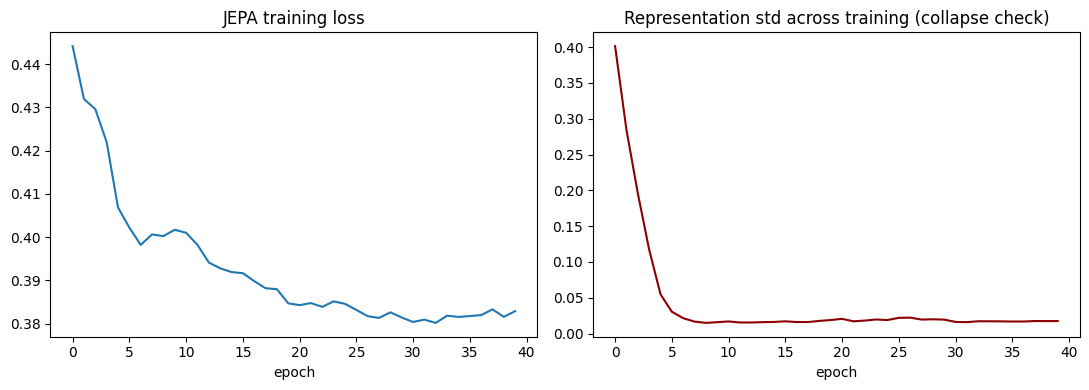

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['loss'])
axes[0].set_title('JEPA training loss'); axes[0].set_xlabel('epoch')
axes[1].plot(history['repr_std'], color='darkred')
axes[1].set_title('Representation std across training (collapse check)')
axes[1].set_xlabel('epoch')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 4. Interpretability analysis

Four lenses on the trained target encoder's representations:
1. **Effective rank per layer** — a soft collapse metric (low effective rank
   relative to embedding dim = representations only vary along a few directions)
2. **Attention entropy per layer** — broad vs. focused attention by depth
3. **Linear probe accuracy per layer** — where class-relevant information
   concentrates in a frozen encoder
4. **Sparse Autoencoder on the target-encoder representations** — do JEPA
   features decompose sparsely, and how many are "dead" (never fire)?

In [10]:
from analysis.probe import (
    collect_layer_representations, effective_rank,
    attention_entropy_per_layer, train_linear_probe,
)
from analysis.sae import train_sae, feature_sparsity_stats

model.eval()

N_PROBE = 4000
train_imgs = torch.stack([train_set[i][0] for i in range(N_PROBE)])
train_labels = torch.tensor([train_set[i][1] for i in range(N_PROBE)])
test_imgs = torch.stack([test_set[i][0] for i in range(min(N_PROBE, len(test_set)))])
test_labels = torch.tensor([test_set[i][1] for i in range(min(N_PROBE, len(test_set)))])

print('collecting per-layer representations...')
train_layer_reps = collect_layer_representations(model, train_imgs, device)
test_layer_reps = collect_layer_representations(model, test_imgs, device)
depth = len(train_layer_reps)
print('depth:', depth)

collecting per-layer representations...
depth: 6


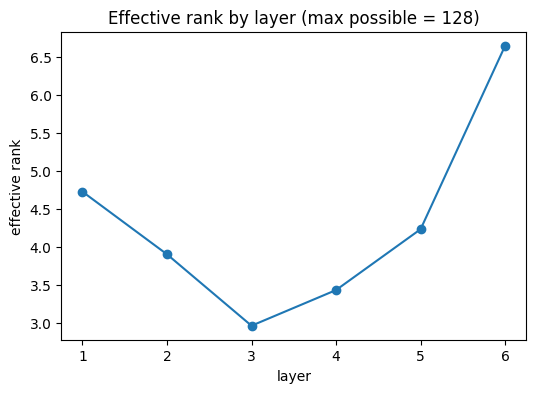

effective rank by layer: [4.7, 3.9, 3.0, 3.4, 4.2, 6.6]


In [11]:
eff_ranks = [effective_rank(r) for r in train_layer_reps]
stds = [r.std(dim=0).mean().item() for r in train_layer_reps]

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), eff_ranks, marker='o')
plt.xlabel('layer'); plt.ylabel('effective rank')
plt.title(f'Effective rank by layer (max possible = {EMBED_DIM})')
plt.savefig('effective_rank_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('effective rank by layer:', [round(x,1) for x in eff_ranks])

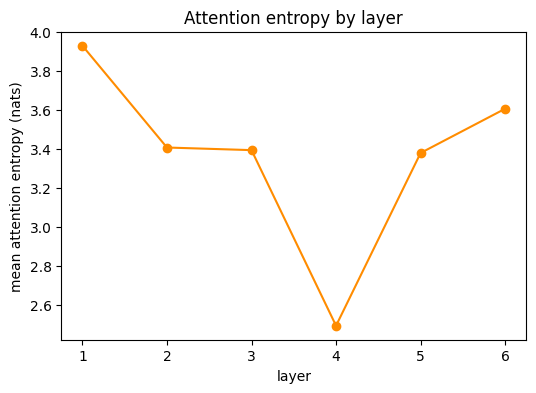

attention entropy by layer: [3.931, 3.409, 3.396, 2.496, 3.381, 3.608]


In [12]:
entropies = attention_entropy_per_layer(model, train_imgs[:512], device)

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), entropies, marker='o', color='darkorange')
plt.xlabel('layer'); plt.ylabel('mean attention entropy (nats)')
plt.title('Attention entropy by layer')
plt.savefig('attention_entropy_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('attention entropy by layer:', [round(x,3) for x in entropies])

layer 1/6: linear probe test acc = 0.2490
layer 2/6: linear probe test acc = 0.2273
layer 3/6: linear probe test acc = 0.2065
layer 4/6: linear probe test acc = 0.2135
layer 5/6: linear probe test acc = 0.2025
layer 6/6: linear probe test acc = 0.2035


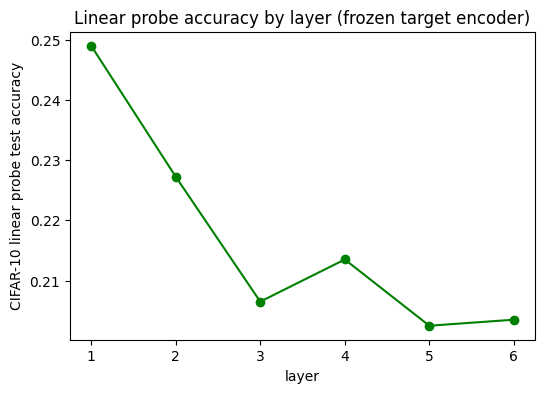

best layer: 1 acc = 0.24900001287460327


In [13]:
probe_accs = []
for i in range(depth):
    acc = train_linear_probe(
        train_layer_reps[i], train_labels, test_layer_reps[i], test_labels,
        epochs=150, lr=1e-2, device=device,
    )
    probe_accs.append(acc)
    print(f'layer {i+1}/{depth}: linear probe test acc = {acc:.4f}')

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), probe_accs, marker='o', color='green')
plt.xlabel('layer'); plt.ylabel('CIFAR-10 linear probe test accuracy')
plt.title('Linear probe accuracy by layer (frozen target encoder)')
plt.savefig('linear_probe_acc_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('best layer:', probe_accs.index(max(probe_accs)) + 1, 'acc =', max(probe_accs))

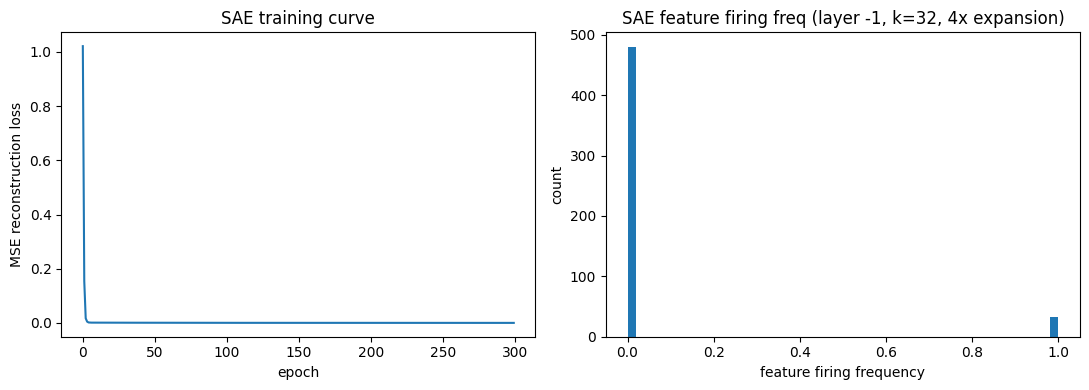

final SAE recon loss: 0.0002
dead feature fraction: 93.0%
mean firing frequency: 0.0625


In [14]:
SAE_LAYER = -1   # last layer; try a middle layer too and compare
SAE_EXPANSION = 4
SAE_K = 32

sae_reps = train_layer_reps[SAE_LAYER]
sae, sae_losses = train_sae(sae_reps, expansion=SAE_EXPANSION, k=SAE_K, epochs=300, device=device)
freq = feature_sparsity_stats(sae, sae_reps, device=device)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(sae_losses)
plt.xlabel('epoch'); plt.ylabel('MSE reconstruction loss')
plt.title('SAE training curve')

plt.subplot(1,2,2)
plt.hist(freq.cpu().numpy(), bins=50)
plt.xlabel('feature firing frequency'); plt.ylabel('count')
plt.title(f'SAE feature firing freq (layer {SAE_LAYER}, k={SAE_K}, {SAE_EXPANSION}x expansion)')
plt.tight_layout()
plt.savefig('sae_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

dead_frac = (freq == 0).float().mean().item()
print(f'final SAE recon loss: {sae_losses[-1]:.4f}')
print(f'dead feature fraction: {dead_frac*100:.1f}%')
print(f'mean firing frequency: {freq.mean().item():.4f}')

## 5. Optional: compare SAE on an early vs. late layer

Your existing CV project found a dense to sparse gradient across Qwen3 layers.
This cell checks whether the same pattern shows up in JEPA's representations —
run it if you have time before the deadline; it's a strong, directly comparable
finding to put in a CV bullet.

In [15]:
EARLY_LAYER = 1  # 0-indexed; adjust based on `depth` above

early_reps = train_layer_reps[EARLY_LAYER]
late_reps = train_layer_reps[-1]

sae_early, losses_early = train_sae(early_reps, expansion=SAE_EXPANSION, k=SAE_K, epochs=300, device=device)
freq_early = feature_sparsity_stats(sae_early, early_reps, device=device)

print(f'EARLY layer {EARLY_LAYER+1}: dead_frac={((freq_early==0).float().mean().item())*100:.1f}%  mean_freq={freq_early.mean().item():.4f}  recon_loss={losses_early[-1]:.4f}')
print(f'LATE  layer {depth}: dead_frac={dead_frac*100:.1f}%  mean_freq={freq.mean().item():.4f}  recon_loss={sae_losses[-1]:.4f}')

EARLY layer 2: dead_frac=92.6%  mean_freq=0.0606  recon_loss=0.0001
LATE  layer 6: dead_frac=93.0%  mean_freq=0.0625  recon_loss=0.0002


## 6. Save everything

Collects all numbers into `results.json` for writing up findings (CV bullets,
statement of purpose, etc).

In [16]:
import json

results = {
    'config': dict(epochs=EPOCHS, embed_dim=EMBED_DIM, enc_depth=ENC_DEPTH,
                    enc_heads=ENC_HEADS, pred_dim=PRED_DIM, pred_depth=PRED_DEPTH),
    'final_train_loss': history['loss'][-1],
    'final_repr_std': history['repr_std'][-1],
    'effective_rank_by_layer': eff_ranks,
    'attention_entropy_by_layer': entropies,
    'linear_probe_acc_by_layer': probe_accs,
    'best_probe_layer': probe_accs.index(max(probe_accs)) + 1,
    'best_probe_acc': max(probe_accs),
    'sae_final_recon_loss': sae_losses[-1],
    'sae_dead_feature_frac': dead_frac,
    'sae_mean_firing_freq': freq.mean().item(),
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "config": {
    "epochs": 40,
    "embed_dim": 128,
    "enc_depth": 6,
    "enc_heads": 4,
    "pred_dim": 64,
    "pred_depth": 3
  },
  "final_train_loss": 0.3828801200940059,
  "final_repr_std": 0.017549481242895126,
  "effective_rank_by_layer": [
    4.7241315841674805,
    3.8992836475372314,
    2.9584128856658936,
    3.428152322769165,
    4.229522228240967,
    6.645970821380615
  ],
  "attention_entropy_by_layer": [
    3.9308385848999023,
    3.40910005569458,
    3.3957221508026123,
    2.4957613945007324,
    3.3810901641845703,
    3.6078290939331055
  ],
  "linear_probe_acc_by_layer": [
    0.24900001287460327,
    0.22725000977516174,
    0.20650000870227814,
    0.2135000079870224,
    0.20250001549720764,
    0.20350000262260437
  ],
  "best_probe_layer": 1,
  "best_probe_acc": 0.24900001287460327,
  "sae_final_recon_loss": 0.00023834226408507675,
  "sae_dead_feature_frac": 0.9296875,
  "sae_mean_firing_freq": 0.0625
}


## 3b. Anti-collapse fix: VICReg-style variance regularization

If your Section 3 run showed `repr_std` collapsing toward 0 (check the plot
above — if it flattens near 0 within the first ~10-15 epochs, that's
collapse), run this section to train a second model with an explicit
anti-collapse regularizer and compare directly against the baseline.

**What this adds**: a variance penalty (Bardes et al., 2022 / VICReg) on the
context encoder's pooled representations — a hinge loss that pushes the
per-dimension std of each batch's representations up toward a target `gamma`,
independent of whatever the prediction loss alone would allow. Optionally
also a covariance penalty that discourages different dimensions from
encoding redundant (correlated) signal. Both are 0-weighted by default in
`JEPA`, so this doesn't change Section 3's behavior — it's a genuinely new
run, not a silent change to the old one.

We're also lowering `ema_momentum` from 0.996 to 0.99, since 40 epochs may
simply be too few steps for a 0.996 momentum target to move meaningfully —
the target encoder was likely chasing an almost-frozen (near-random) teacher
for most of training.

In [21]:
%%writefile model/jepa.py
"""
Minimal I-JEPA implementation.

Core idea (Assran et al., 2023): instead of reconstructing masked pixels
(MAE) or contrastive instance discrimination (SimCLR), JEPA predicts the
*representation* of masked target patches from the representation of
visible context patches, using a separate predictor network. The target
encoder is an EMA (exponential moving average) copy of the context
encoder, and gradients never flow into it (stop-gradient) -- this, plus
the asymmetric predictor, is what prevents representation collapse
(everything mapping to a constant vector), which is the central failure
mode this whole architecture is designed around.

Components:
  - PatchEmbed: image -> patch tokens
  - ViTEncoder: standard pre-norm transformer encoder (used for both
    context and target encoders; target is an EMA copy, never trained
    by gradient descent)
  - Predictor: small transformer that takes context tokens + mask tokens
    (with positional embeddings for the masked positions) and predicts
    target-encoder representations at those positions
  - JEPA: wraps the above, implements masking + EMA update + loss
"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def build_2d_sincos_pos_embed(embed_dim, grid_size):
    """Fixed sin-cos positional embeddings, standard ViT/MAE recipe."""
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_w, grid_h, indexing="ij")
    grid = torch.stack(grid, dim=0).reshape(2, 1, grid_size, grid_size)

    assert embed_dim % 4 == 0
    dim_half = embed_dim // 2

    def sincos_1d(pos, dim):
        omega = torch.arange(dim // 2, dtype=torch.float32)
        omega = 1.0 / (10000 ** (omega / (dim // 2)))
        pos = pos.reshape(-1)
        out = pos[:, None] * omega[None, :]
        return torch.cat([torch.sin(out), torch.cos(out)], dim=1)

    emb_h = sincos_1d(grid[0], dim_half)
    emb_w = sincos_1d(grid[1], dim_half)
    return torch.cat([emb_h, emb_w], dim=1)  # (grid_size**2, embed_dim)


class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128):
        super().__init__()
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)               # (B, C, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, N, C)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim)
        )

    def forward(self, x, return_attn=False):
        h = self.norm1(x)
        attn_out, attn_weights = self.attn(h, h, h, need_weights=return_attn, average_attn_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        if return_attn:
            return x, attn_weights
        return x


class ViTEncoder(nn.Module):
    """Used for both context encoder (trained) and target encoder (EMA copy)."""

    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128,
                 depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        grid_size = self.patch_embed.grid_size

        pos_embed = build_2d_sincos_pos_embed(embed_dim, grid_size)
        self.register_buffer("pos_embed", pos_embed.unsqueeze(0))  # (1, N, D)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim
        self.num_patches = num_patches

    def forward(self, x, patch_indices=None, return_all_layers=False, return_attn=False):
        """
        x: (B, C, H, W) images
        patch_indices: optional (B, K) indices of patches to keep (context encoder
            only sees these -- this is what makes it a *context* encoder)
        return_all_layers: if True, also return list of per-block outputs (for
            interpretability probing across depth)
        """
        tokens = self.patch_embed(x)  # (B, N, D)
        tokens = tokens + self.pos_embed

        if patch_indices is not None:
            B, K = patch_indices.shape
            idx = patch_indices.unsqueeze(-1).expand(-1, -1, tokens.shape[-1])
            tokens = torch.gather(tokens, 1, idx)  # (B, K, D)

        all_layers = []
        all_attn = []
        for blk in self.blocks:
            if return_attn:
                tokens, attn = blk(tokens, return_attn=True)
                all_attn.append(attn)
            else:
                tokens = blk(tokens)
            if return_all_layers:
                all_layers.append(tokens)

        tokens = self.norm(tokens)

        out = {"tokens": tokens}
        if return_all_layers:
            out["all_layers"] = all_layers
        if return_attn:
            out["all_attn"] = all_attn
        return out


class Predictor(nn.Module):
    """Narrow transformer: context tokens + mask tokens -> predicted target reps."""

    def __init__(self, embed_dim=128, predictor_dim=64, depth=3, num_heads=4, grid_size=8):
        super().__init__()
        self.embed_in = nn.Linear(embed_dim, predictor_dim)
        self.embed_out = nn.Linear(predictor_dim, embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)

        pos_embed = build_2d_sincos_pos_embed(predictor_dim, grid_size)
        self.register_buffer("pos_embed", pos_embed.unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(predictor_dim, num_heads, mlp_ratio=4.0) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(predictor_dim)

    def forward(self, context_tokens, context_indices, target_indices):
        """
        context_tokens: (B, K_ctx, D) output of context encoder
        context_indices: (B, K_ctx) which patch positions these are
        target_indices: (B, K_tgt) which patch positions to predict
        """
        B = context_tokens.shape[0]
        D = self.mask_token.shape[-1]

        ctx = self.embed_in(context_tokens)
        ctx_pos = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            context_indices.unsqueeze(-1).expand(-1, -1, self.pos_embed.shape[-1])
        )
        ctx = ctx + ctx_pos

        K_tgt = target_indices.shape[1]
        mask_tokens = self.mask_token.expand(B, K_tgt, -1)
        tgt_pos = torch.gather(
            self.pos_embed.expand(B, -1, -1), 1,
            target_indices.unsqueeze(-1).expand(-1, -1, self.pos_embed.shape[-1])
        )
        mask_tokens = mask_tokens + tgt_pos

        x = torch.cat([ctx, mask_tokens], dim=1)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        pred = x[:, ctx.shape[1]:]  # only the (formerly) mask-token positions
        return self.embed_out(pred)  # (B, K_tgt, embed_dim)


def block_mask(num_patches, grid_size, batch_size, device,
                num_target_blocks=4, target_scale=(0.15, 0.2),
                context_scale=(0.85, 1.0)):
    """
    I-JEPA style block masking: sample a handful of rectangular target
    blocks (what the predictor must guess) and a large context region
    (what the context encoder is allowed to see), with target regions
    removed from the context so the task can't be solved by copying.
    Returns index tensors, NOT boolean masks, since we gather() patches.
    """
    def sample_block_indices(scale_range):
        area = grid_size * grid_size
        target_area = area * (scale_range[0] + torch.rand(1).item() * (scale_range[1] - scale_range[0]))
        aspect = 0.75 + torch.rand(1).item() * 0.5
        h = max(1, min(grid_size, round(math.sqrt(target_area * aspect))))
        w = max(1, min(grid_size, round(math.sqrt(target_area / aspect))))
        top = torch.randint(0, grid_size - h + 1, (1,)).item()
        left = torch.randint(0, grid_size - w + 1, (1,)).item()
        idx = []
        for i in range(top, top + h):
            for j in range(left, left + w):
                idx.append(i * grid_size + j)
        return set(idx)

    all_context_idx, all_target_idx = [], []
    for _ in range(batch_size):
        target_set = set()
        for _ in range(num_target_blocks):
            target_set |= sample_block_indices(target_scale)
        context_set = sample_block_indices(context_scale)
        context_set = context_set - target_set  # no leakage

        if len(context_set) == 0:
            context_set = set(range(num_patches)) - target_set
        if len(target_set) == 0:
            target_set = {torch.randint(0, num_patches, (1,)).item()}

        all_context_idx.append(sorted(context_set))
        all_target_idx.append(sorted(target_set))

    min_ctx = min(len(x) for x in all_context_idx)
    min_tgt = min(len(x) for x in all_target_idx)
    all_context_idx = [x[:min_ctx] for x in all_context_idx]
    all_target_idx = [x[:min_tgt] for x in all_target_idx]

    context_indices = torch.tensor(all_context_idx, device=device, dtype=torch.long)
    target_indices = torch.tensor(all_target_idx, device=device, dtype=torch.long)
    return context_indices, target_indices


def variance_loss(x, gamma=1.0, eps=1e-4):
    """
    VICReg variance term (Bardes et al., 2022): a hinge penalty that pushes
    the per-dimension std of a batch of representations up toward `gamma`.
    Unlike JEPA's base loss (which only asks "does the predictor match the
    target"), this term directly discourages the encoder from collapsing
    every input to the same vector, regardless of what the predictor loss
    alone would allow. `gamma=1.0` is the value used in the original VICReg
    paper; representations with std >= gamma pay zero penalty.
    """
    std = torch.sqrt(x.var(dim=0) + eps)
    return torch.relu(gamma - std).mean()


def covariance_loss(x):
    """
    VICReg covariance term: penalizes off-diagonal covariance between
    representation dimensions, which discourages different dimensions from
    encoding redundant (correlated) information -- a subtler form of
    collapse than variance collapse, where std stays healthy but every
    dimension ends up carrying the same signal.
    """
    x = x - x.mean(dim=0)
    n, d = x.shape
    cov = (x.T @ x) / (n - 1)
    off_diag = cov - torch.diag(torch.diagonal(cov))
    return (off_diag ** 2).sum() / d


class JEPA(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128,
                 enc_depth=6, enc_heads=4, pred_dim=64, pred_depth=3, pred_heads=4,
                 ema_momentum=0.996, var_loss_weight=0.0, var_gamma=1.0,
                 cov_loss_weight=0.0):
        super().__init__()
        grid_size = img_size // patch_size
        self.context_encoder = ViTEncoder(img_size, patch_size, in_chans, embed_dim, enc_depth, enc_heads)
        self.target_encoder = ViTEncoder(img_size, patch_size, in_chans, embed_dim, enc_depth, enc_heads)
        self.predictor = Predictor(embed_dim, pred_dim, pred_depth, pred_heads, grid_size)

        # target encoder starts identical to context encoder, then is EMA-only
        self.target_encoder.load_state_dict(self.context_encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad = False

        self.ema_momentum = ema_momentum
        self.num_patches = self.context_encoder.num_patches

        # anti-collapse regularization, applied to the CONTEXT encoder's
        # pooled representations (the branch gradients actually flow through).
        # Both default to 0.0 (disabled) so existing behavior is unchanged
        # unless explicitly turned on.
        self.var_loss_weight = var_loss_weight
        self.var_gamma = var_gamma
        self.cov_loss_weight = cov_loss_weight

    @torch.no_grad()
    def update_target_encoder(self):
        m = self.ema_momentum
        for p_ctx, p_tgt in zip(self.context_encoder.parameters(), self.target_encoder.parameters()):
            p_tgt.data.mul_(m).add_(p_ctx.data, alpha=1 - m)

    def forward(self, images):
        B = images.shape[0]
        device = images.device
        grid_size = self.context_encoder.patch_embed.grid_size

        context_indices, target_indices = block_mask(
            self.num_patches, grid_size, B, device
        )

        ctx_out = self.context_encoder(images, patch_indices=context_indices)
        pred = self.predictor(ctx_out["tokens"], context_indices, target_indices)

        with torch.no_grad():
            tgt_out = self.target_encoder(images)  # full image, no masking
            target_full = tgt_out["tokens"]
            idx = target_indices.unsqueeze(-1).expand(-1, -1, target_full.shape[-1])
            target = torch.gather(target_full, 1, idx)
            target = F.layer_norm(target, (target.shape[-1],))  # stabilizes scale, standard trick

        pred_loss = F.smooth_l1_loss(pred, target)

        logs = {"pred_loss": pred_loss.item()}
        loss = pred_loss

        if self.var_loss_weight > 0 or self.cov_loss_weight > 0:
            ctx_pooled = ctx_out["tokens"].mean(dim=1)  # (B, D), pooled context representation

        if self.var_loss_weight > 0:
            v_loss = variance_loss(ctx_pooled, gamma=self.var_gamma)
            loss = loss + self.var_loss_weight * v_loss
            logs["var_loss"] = v_loss.item()

        if self.cov_loss_weight > 0:
            c_loss = covariance_loss(ctx_pooled)
            loss = loss + self.cov_loss_weight * c_loss
            logs["cov_loss"] = c_loss.item()

        return loss, {"pred": pred, "target": target, "logs": logs}


Overwriting model/jepa.py


In [ ]:
import importlib
import model.jepa as jepa_mod
importlib.reload(jepa_mod)
from model.jepa import JEPA

In [24]:
VAR_LOSS_WEIGHT = 5.0
VAR_GAMMA = 1.0
COV_LOSS_WEIGHT = 1.0
EMA_MOMENTUM_FIXED = 0.99

model_fixed = JEPA(
    img_size=32, patch_size=4, embed_dim=EMBED_DIM,
    enc_depth=ENC_DEPTH, enc_heads=ENC_HEADS,
    pred_dim=PRED_DIM, pred_depth=PRED_DEPTH,
    ema_momentum=EMA_MOMENTUM_FIXED,
    var_loss_weight=VAR_LOSS_WEIGHT, var_gamma=VAR_GAMMA,
    cov_loss_weight=COV_LOSS_WEIGHT,
).to(device)

opt_fixed = torch.optim.AdamW(model_fixed.context_encoder.parameters(), lr=3e-4, weight_decay=0.05)
sched_fixed = torch.optim.lr_scheduler.OneCycleLR(opt_fixed, max_lr=3e-4, total_steps=total_steps, pct_start=0.1)

history_fixed = {'loss': [], 'pred_loss': [], 'var_loss': [], 'repr_std': []}
for epoch in range(EPOCHS):
    model_fixed.train()
    running, running_pred, running_var = 0.0, 0.0, 0.0
    for images, _ in train_loader:
        images = images.to(device)
        loss, out = model_fixed(images)
        opt_fixed.zero_grad()
        loss.backward()
        opt_fixed.step()
        sched_fixed.step()
        model_fixed.update_target_encoder()
        running += loss.item()
        running_pred += out['logs']['pred_loss']
        running_var += out['logs'].get('var_loss', 0.0)
    avg_loss = running / len(train_loader)
    avg_pred = running_pred / len(train_loader)
    avg_var = running_var / len(train_loader)
    std = representation_std(model_fixed, probe_images)
    history_fixed['loss'].append(avg_loss)
    history_fixed['pred_loss'].append(avg_pred)
    history_fixed['var_loss'].append(avg_var)
    history_fixed['repr_std'].append(std)
    print(f'epoch {epoch+1:3d}/{EPOCHS}  total_loss={avg_loss:.4f}  pred_loss={avg_pred:.4f}  var_loss={avg_var:.4f}  repr_std={std:.4f}')

torch.save(model_fixed.state_dict(), 'jepa_fixed_final.pt')
print('regularized run done, checkpoint saved.')

epoch   1/40  total_loss=4.3576  pred_loss=0.5002  var_loss=0.6035  repr_std=0.2652
epoch   2/40  total_loss=2.8477  pred_loss=0.4723  var_loss=0.3237  repr_std=0.5020
epoch   3/40  total_loss=1.8232  pred_loss=0.5080  var_loss=0.1052  repr_std=0.7779
epoch   4/40  total_loss=1.4730  pred_loss=0.5122  var_loss=0.0510  repr_std=0.8739
epoch   5/40  total_loss=1.2986  pred_loss=0.5107  var_loss=0.0331  repr_std=0.9147
epoch   6/40  total_loss=1.2223  pred_loss=0.5080  var_loss=0.0263  repr_std=0.9337
epoch   7/40  total_loss=1.1898  pred_loss=0.5044  var_loss=0.0234  repr_std=0.9453
epoch   8/40  total_loss=1.1740  pred_loss=0.5018  var_loss=0.0218  repr_std=0.9519
epoch   9/40  total_loss=1.1609  pred_loss=0.4995  var_loss=0.0206  repr_std=0.9565
epoch  10/40  total_loss=1.1472  pred_loss=0.4961  var_loss=0.0198  repr_std=0.9610
epoch  11/40  total_loss=1.1476  pred_loss=0.4937  var_loss=0.0198  repr_std=0.9641
epoch  12/40  total_loss=1.1329  pred_loss=0.4908  var_loss=0.0187  repr_std

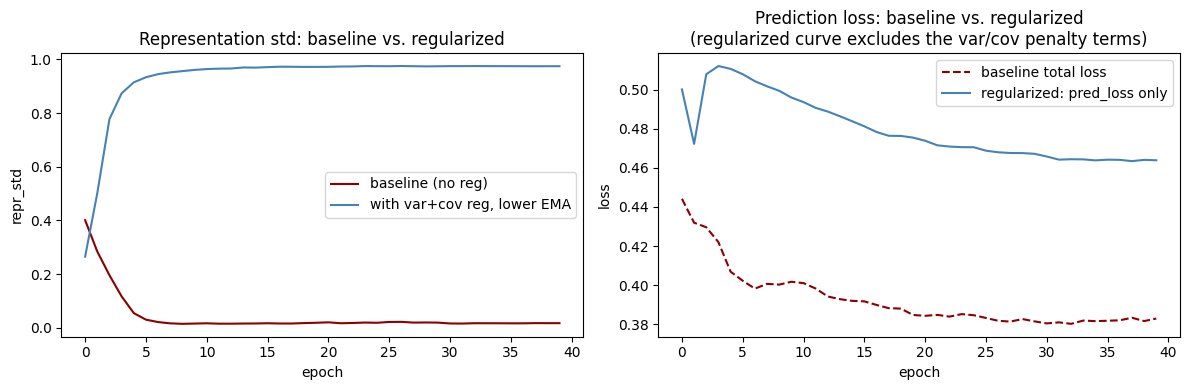

baseline final repr_std:    0.0175
regularized final repr_std: 0.9749
ratio (regularized / baseline): 55.55x


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['repr_std'], label='baseline (no reg)', color='darkred')
axes[0].plot(history_fixed['repr_std'], label='with var+cov reg, lower EMA', color='steelblue')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('repr_std')
axes[0].set_title('Representation std: baseline vs. regularized')
axes[0].legend()

axes[1].plot(history['loss'], label='baseline total loss', color='darkred', linestyle='--')
axes[1].plot(history_fixed['pred_loss'], label='regularized: pred_loss only', color='steelblue')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss')
axes[1].set_title('Prediction loss: baseline vs. regularized\n(regularized curve excludes the var/cov penalty terms)')
axes[1].legend()

plt.tight_layout()
plt.savefig('collapse_fix_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"baseline final repr_std:    {history['repr_std'][-1]:.4f}")
print(f"regularized final repr_std: {history_fixed['repr_std'][-1]:.4f}")
print(f"ratio (regularized / baseline): {history_fixed['repr_std'][-1] / max(history['repr_std'][-1], 1e-8):.2f}x")

**Which model to run the interpretability analysis on next:** if the
regularized run shows a meaningfully higher final `repr_std` (the print
statement above shows the ratio), switch the `model` variable used in
Section 4 onward to `model_fixed` by running the cell below. If it *didn't*
help much, that's also a valid, reportable finding — it would suggest the
collapse has a cause other than pure variance collapse (e.g. genuinely
insufficient training epochs, or the block-masking task being too easy at
this image resolution/patch size for one of the two encoders), which is
worth stating explicitly rather than glossing over.

In [26]:
USE_FIXED_MODEL_FOR_ANALYSIS = True  # set False to keep analyzing the original baseline model

if USE_FIXED_MODEL_FOR_ANALYSIS:
    model = model_fixed
    print('Using the variance-regularized model for the interpretability analysis below.')
else:
    print('Using the original baseline model for the interpretability analysis below.')

Using the variance-regularized model for the interpretability analysis below.


## 4. Interpretability analysis

Four lenses on the trained target encoder's representations:
1. **Effective rank per layer** — a soft collapse metric (low effective rank
   relative to embedding dim = representations only vary along a few directions)
2. **Attention entropy per layer** — broad vs. focused attention by depth
3. **Linear probe accuracy per layer** — where class-relevant information
   concentrates in a frozen encoder
4. **Sparse Autoencoder on the target-encoder representations** — do JEPA
   features decompose sparsely, and how many are "dead" (never fire)?

In [27]:
from analysis.probe import (
    collect_layer_representations, effective_rank,
    attention_entropy_per_layer, train_linear_probe,
)
from analysis.sae import train_sae, feature_sparsity_stats

model.eval()

N_PROBE = 4000
train_imgs = torch.stack([train_set[i][0] for i in range(N_PROBE)])
train_labels = torch.tensor([train_set[i][1] for i in range(N_PROBE)])
test_imgs = torch.stack([test_set[i][0] for i in range(min(N_PROBE, len(test_set)))])
test_labels = torch.tensor([test_set[i][1] for i in range(min(N_PROBE, len(test_set)))])

print('collecting per-layer representations...')
train_layer_reps = collect_layer_representations(model, train_imgs, device)
test_layer_reps = collect_layer_representations(model, test_imgs, device)
depth = len(train_layer_reps)
print('depth:', depth)

collecting per-layer representations...
depth: 6


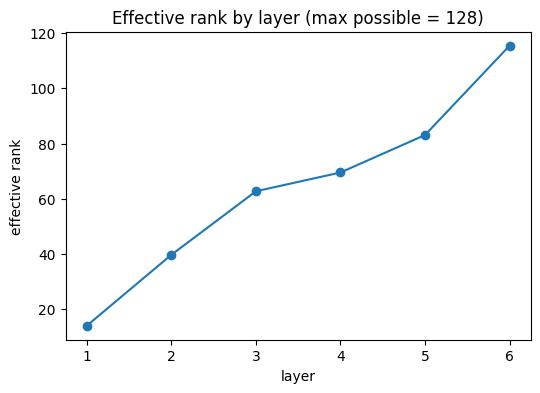

effective rank by layer: [14.1, 39.7, 62.7, 69.5, 83.0, 115.4]


In [28]:
eff_ranks = [effective_rank(r) for r in train_layer_reps]
stds = [r.std(dim=0).mean().item() for r in train_layer_reps]

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), eff_ranks, marker='o')
plt.xlabel('layer'); plt.ylabel('effective rank')
plt.title(f'Effective rank by layer (max possible = {EMBED_DIM})')
plt.savefig('effective_rank_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('effective rank by layer:', [round(x,1) for x in eff_ranks])

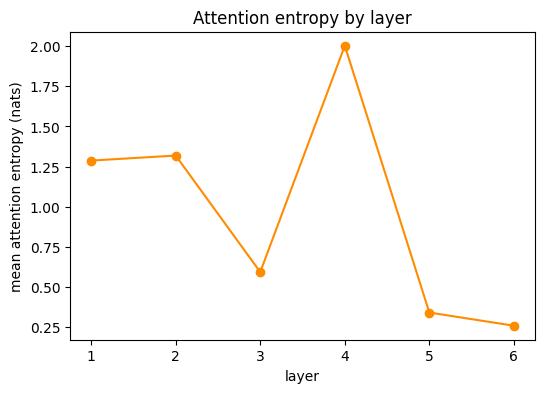

attention entropy by layer: [1.288, 1.319, 0.594, 2.002, 0.342, 0.26]


In [29]:
entropies = attention_entropy_per_layer(model, train_imgs[:512], device)

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), entropies, marker='o', color='darkorange')
plt.xlabel('layer'); plt.ylabel('mean attention entropy (nats)')
plt.title('Attention entropy by layer')
plt.savefig('attention_entropy_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('attention entropy by layer:', [round(x,3) for x in entropies])

layer 1/6: linear probe test acc = 0.3505
layer 2/6: linear probe test acc = 0.3623
layer 3/6: linear probe test acc = 0.3698
layer 4/6: linear probe test acc = 0.3865
layer 5/6: linear probe test acc = 0.3728
layer 6/6: linear probe test acc = 0.3303


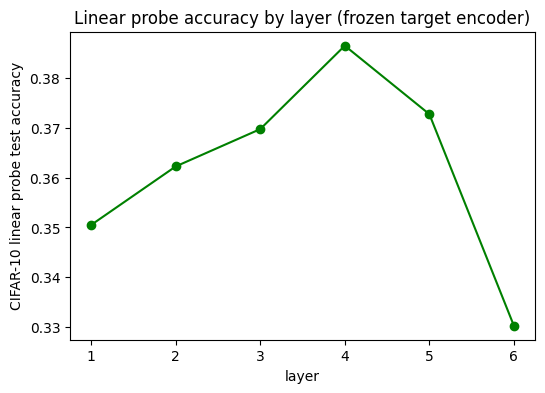

best layer: 4 acc = 0.3865000307559967


In [30]:
probe_accs = []
for i in range(depth):
    acc = train_linear_probe(
        train_layer_reps[i], train_labels, test_layer_reps[i], test_labels,
        epochs=150, lr=1e-2, device=device,
    )
    probe_accs.append(acc)
    print(f'layer {i+1}/{depth}: linear probe test acc = {acc:.4f}')

plt.figure(figsize=(6,4))
plt.plot(range(1, depth+1), probe_accs, marker='o', color='green')
plt.xlabel('layer'); plt.ylabel('CIFAR-10 linear probe test accuracy')
plt.title('Linear probe accuracy by layer (frozen target encoder)')
plt.savefig('linear_probe_acc_by_layer.png', dpi=120, bbox_inches='tight')
plt.show()
print('best layer:', probe_accs.index(max(probe_accs)) + 1, 'acc =', max(probe_accs))

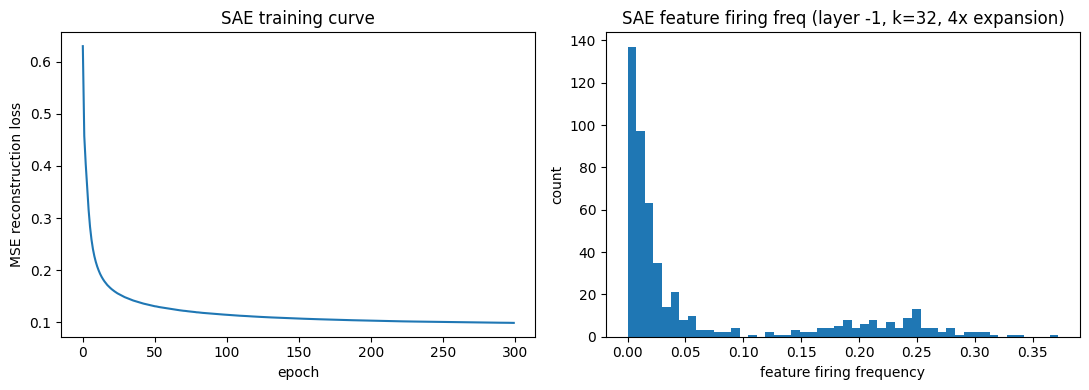

final SAE recon loss: 0.0986
dead feature fraction: 15.2%
mean firing frequency: 0.0625


In [31]:
SAE_LAYER = -1   # last layer; try a middle layer too and compare
SAE_EXPANSION = 4
SAE_K = 32

sae_reps = train_layer_reps[SAE_LAYER]
sae, sae_losses = train_sae(sae_reps, expansion=SAE_EXPANSION, k=SAE_K, epochs=300, device=device)
freq = feature_sparsity_stats(sae, sae_reps, device=device)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(sae_losses)
plt.xlabel('epoch'); plt.ylabel('MSE reconstruction loss')
plt.title('SAE training curve')

plt.subplot(1,2,2)
plt.hist(freq.cpu().numpy(), bins=50)
plt.xlabel('feature firing frequency'); plt.ylabel('count')
plt.title(f'SAE feature firing freq (layer {SAE_LAYER}, k={SAE_K}, {SAE_EXPANSION}x expansion)')
plt.tight_layout()
plt.savefig('sae_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

dead_frac = (freq == 0).float().mean().item()
print(f'final SAE recon loss: {sae_losses[-1]:.4f}')
print(f'dead feature fraction: {dead_frac*100:.1f}%')
print(f'mean firing frequency: {freq.mean().item():.4f}')

## 5. Optional: compare SAE on an early vs. late layer

Your existing CV project found a dense to sparse gradient across Qwen3 layers.
This cell checks whether the same pattern shows up in JEPA's representations —
run it if you have time before the deadline; it's a strong, directly comparable
finding to put in a CV bullet.

In [32]:
EARLY_LAYER = 1  # 0-indexed; adjust based on `depth` above

early_reps = train_layer_reps[EARLY_LAYER]
late_reps = train_layer_reps[-1]

sae_early, losses_early = train_sae(early_reps, expansion=SAE_EXPANSION, k=SAE_K, epochs=300, device=device)
freq_early = feature_sparsity_stats(sae_early, early_reps, device=device)

print(f'EARLY layer {EARLY_LAYER+1}: dead_frac={((freq_early==0).float().mean().item())*100:.1f}%  mean_freq={freq_early.mean().item():.4f}  recon_loss={losses_early[-1]:.4f}')
print(f'LATE  layer {depth}: dead_frac={dead_frac*100:.1f}%  mean_freq={freq.mean().item():.4f}  recon_loss={sae_losses[-1]:.4f}')

EARLY layer 2: dead_frac=81.1%  mean_freq=0.0625  recon_loss=0.0116
LATE  layer 6: dead_frac=15.2%  mean_freq=0.0625  recon_loss=0.0986


## 6. Save everything

Collects all numbers into `results.json` for writing up findings (CV bullets,
statement of purpose, etc).

In [34]:
import json

# NOTE: uses history_fixed / model_fixed's own loss+std, not the baseline's,
# so the numbers here always match whichever model was actually analyzed
# above (controlled by USE_FIXED_MODEL_FOR_ANALYSIS). Also records the
# baseline run alongside it, so the collapse-vs-fixed comparison is fully
# self-contained in one file.
analyzed_history = history_fixed if USE_FIXED_MODEL_FOR_ANALYSIS else history

results = {
    'analyzed_model': 'regularized (model_fixed)' if USE_FIXED_MODEL_FOR_ANALYSIS else 'baseline (model)',
    'baseline_run': {
        'config': dict(epochs=EPOCHS, embed_dim=EMBED_DIM, enc_depth=ENC_DEPTH,
                        enc_heads=ENC_HEADS, pred_dim=PRED_DIM, pred_depth=PRED_DEPTH,
                        ema_momentum=0.996, var_loss_weight=0.0, cov_loss_weight=0.0),
        'final_train_loss': history['loss'][-1],
        'final_repr_std': history['repr_std'][-1],
    },
    'regularized_run': {
        'config': dict(epochs=EPOCHS, embed_dim=EMBED_DIM, enc_depth=ENC_DEPTH,
                        enc_heads=ENC_HEADS, pred_dim=PRED_DIM, pred_depth=PRED_DEPTH,
                        ema_momentum=EMA_MOMENTUM_FIXED, var_loss_weight=VAR_LOSS_WEIGHT,
                        var_gamma=VAR_GAMMA, cov_loss_weight=COV_LOSS_WEIGHT),
        'final_total_loss': history_fixed['loss'][-1],
        'final_pred_loss': history_fixed['pred_loss'][-1],
        'final_var_loss': history_fixed['var_loss'][-1],
        'final_repr_std': history_fixed['repr_std'][-1],
    },
    'repr_std_improvement_ratio': history_fixed['repr_std'][-1] / max(history['repr_std'][-1], 1e-8),
    # everything below is from whichever model was actually analyzed (see 'analyzed_model' above)
    'effective_rank_by_layer': eff_ranks,
    'attention_entropy_by_layer': entropies,
    'linear_probe_acc_by_layer': probe_accs,
    'best_probe_layer': probe_accs.index(max(probe_accs)) + 1,
    'best_probe_acc': max(probe_accs),
    'sae_final_recon_loss': sae_losses[-1],
    'sae_dead_feature_frac': dead_frac,
    'sae_mean_firing_freq': freq.mean().item(),
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "analyzed_model": "regularized (model_fixed)",
  "baseline_run": {
    "config": {
      "epochs": 40,
      "embed_dim": 128,
      "enc_depth": 6,
      "enc_heads": 4,
      "pred_dim": 64,
      "pred_depth": 3,
      "ema_momentum": 0.996,
      "var_loss_weight": 0.0,
      "cov_loss_weight": 0.0
    },
    "final_train_loss": 0.3828801200940059,
    "final_repr_std": 0.017549481242895126
  },
  "regularized_run": {
    "config": {
      "epochs": 40,
      "embed_dim": 128,
      "enc_depth": 6,
      "enc_heads": 4,
      "pred_dim": 64,
      "pred_depth": 3,
      "ema_momentum": 0.99,
      "var_loss_weight": 5.0,
      "var_gamma": 1.0,
      "cov_loss_weight": 1.0
    },
    "final_total_loss": 1.055858434163607,
    "final_pred_loss": 0.46392147648028836,
    "final_var_loss": 0.014857971615707262,
    "final_repr_std": 0.9748530983924866
  },
  "repr_std_improvement_ratio": 55.54882705077986,
  "effective_rank_by_layer": [
    14.088912010192871,
    39.7300071716308